# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Satria Musthofa 'Azmi
- **Email:** satriamusthofaazmi@gmail.com
- **ID Dicoding:** satriamusthofaazmi

## Menentukan Pertanyaan Bisnis
- **Pertanyaan 1**: Bagaimana segmentasi pelanggan Olist berdasarkan analisis RFM (Recency, Frequency, Monetary) pada periode transaksi 2017-2018 untuk menentukan strategi retensi pelanggan?
- **Pertanyaan 2**: Bagaimana performa ketepatan waktu pengiriman pesanan dan pengaruh keterlambatan pengiriman terhadap skor kepuasan pelanggan (review score) di 5 negara bagian teratas Brasil sepanjang tahun 2017-2018?

## Menyiapkan semua library yang dibutuhkan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pengaturan visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## Data Wrangling
### Gathering Data

In [2]:
# Memuat dataset yang digunakan
customers_df = pd.read_csv('data/customers_dataset.csv')
orders_df = pd.read_csv('data/orders_dataset.csv')
order_payments_df = pd.read_csv('data/order_payments_dataset.csv')
order_reviews_df = pd.read_csv('data/order_reviews_dataset.csv')
geolocation_df = pd.read_csv('data/geolocation_dataset.csv')

# Menampilkan sampel 5 baris pertama data pesanan
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


### Assessing Data

In [3]:
# Memeriksa informasi struktur dan tipe data
print("--- Info Orders ---")
orders_df.info()

print("\n--- Info Customers ---")
customers_df.info()

print("\n--- Info Payments ---")
order_payments_df.info()

print("\n--- Info Reviews ---")
order_reviews_df.info()

--- Info Orders ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB

--- Info Customers ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [4]:
# Memeriksa missing values dan duplikasi
print("Missing values pada orders:")
print(orders_df.isna().sum())

print("\nMissing values pada reviews:")
print(order_reviews_df.isna().sum())

print("\nJumlah duplikasi pada orders:", orders_df.duplicated().sum())
print("Jumlah duplikasi pada customers:", customers_df.duplicated().sum())
print("Jumlah duplikasi pada geolocation:", geolocation_df.duplicated().sum())

Missing values pada orders:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Missing values pada reviews:
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64



Jumlah duplikasi pada orders: 0
Jumlah duplikasi pada customers: 0


Jumlah duplikasi pada geolocation: 261831


**Temuan Masalah pada Data**:
1. Tipe data kolom tanggal pada `orders_df` masih bertipe `object` dan perlu diubah menjadi `datetime`.
2. Terdapat missing values pada tanggal pengiriman dan teks review yang bersifat opsional.
3. Terdapat banyak duplikasi koordinat per kode pos pada `geolocation_df` yang perlu diagregasi.

### Cleaning Data

In [5]:
# 1. Mengonversi kolom tanggal ke format datetime
date_columns = [
    'order_purchase_timestamp', 
    'order_approved_at', 
    'order_delivered_carrier_date', 
    'order_delivered_customer_date', 
    'order_estimated_delivery_date'
]
for col in date_columns:
    orders_df[col] = pd.to_datetime(orders_df[col])

# 2. Memfilter pesanan berstatus delivered pada periode stabil 2017 sampai Agustus 2018
orders_clean = orders_df[
    (orders_df['order_status'] == 'delivered') &
    (orders_df['order_purchase_timestamp'] >= '2017-01-01') &
    (orders_df['order_purchase_timestamp'] <= '2018-08-31')
].copy()

# 3. Menghitung durasi keterlambatan pengiriman (hari) dan kategori statusnya
orders_clean['delivery_delay_days'] = (
    orders_clean['order_delivered_customer_date'] - orders_clean['order_estimated_delivery_date']
).dt.total_seconds() / (24 * 3600)

orders_clean['delivery_status'] = orders_clean['delivery_delay_days'].apply(
    lambda x: 'Late' if x > 0 else 'On Time'
)

# 4. Agregasi data geolokasi per zip code prefix
geo_clean = geolocation_df.groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean',
    'geolocation_city': 'first',
    'geolocation_state': 'first'
}).reset_index()

print("Jumlah data pesanan bersih:", len(orders_clean))
print("Jumlah kode pos unik geolokasi:", len(geo_clean))

Jumlah data pesanan bersih: 96211
Jumlah kode pos unik geolokasi: 19015


**Tindakan Pembersihan Data**:
- Seluruh kolom penanda waktu telah diubah ke format `datetime`.
- Data pesanan telah disaring hanya untuk transaksi `delivered` periode 2017-2018.
- Keterlambatan pengiriman telah dihitung dan diklasifikasikan ke dalam status `Late` atau `On Time`.
- Duplikasi geolokasi diselesaikan dengan mengambil rata-rata koordinat per kode pos.

## Exploratory Data Analysis (EDA)
### Eksplorasi Pengiriman dan Kepuasan Pelanggan

In [6]:
# Menggabungkan data pesanan dengan data pelanggan dan ulasan
orders_customers = orders_clean.merge(customers_df, on='customer_id', how='inner')
orders_full = orders_customers.merge(
    order_reviews_df[['order_id', 'review_score']], on='order_id', how='left'
)

# Analisis rata-rata skor ulasan berdasarkan status pengiriman
review_summary = orders_full.groupby('delivery_status')['review_score'].agg(['count', 'mean', 'median']).reset_index()
print("Ringkasan Skor Ulasan Berdasarkan Ketepatan Pengiriman:")
print(review_summary)

Ringkasan Skor Ulasan Berdasarkan Ketepatan Pengiriman:
  delivery_status  count      mean  median
0            Late   7697  2.566714     2.0
1         On Time  88398  4.294509     5.0


In [7]:
# Analisis keterlambatan pengiriman pada 5 negara bagian teratas
top_5_states = orders_full['customer_state'].value_counts().head(5).index

state_perf = orders_full[orders_full['customer_state'].isin(top_5_states)].groupby('customer_state').agg(
    total_orders=('order_id', 'count'),
    late_orders=('delivery_status', lambda x: (x == 'Late').sum()),
    avg_review_score=('review_score', 'mean')
).reset_index()

state_perf['late_percentage'] = (state_perf['late_orders'] / state_perf['total_orders']) * 100
state_perf = state_perf.sort_values(by='late_percentage', ascending=False)
print("Performa Pengiriman 5 Negara Bagian Teratas:")
print(state_perf)

Performa Pengiriman 5 Negara Bagian Teratas:
  customer_state  total_orders  late_orders  avg_review_score  late_percentage
2             RJ         12380         1674          3.963486        13.521809
3             RS          5365          386          4.185899         7.194781
4             SP         40617         2390          4.246948         5.884236
0             MG         11386          640          4.193851         5.620938
1             PR          4922          248          4.239437         5.038602


### Eksplorasi Metrik RFM (Recency, Frequency, Monetary)

In [8]:
# Menghitung total pembayaran per pesanan
payment_per_order = order_payments_df.groupby('order_id')['payment_value'].sum().reset_index()
orders_payment = orders_full.merge(payment_per_order, on='order_id', how='left')

# Tanggal referensi untuk perhitungan Recency (1 hari setelah transaksi terakhir)
snapshot_date = orders_payment['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# Agregasi RFM per pelanggan unik
rfm_df = orders_payment.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'nunique',
    'payment_value': 'sum'
}).reset_index()

rfm_df.columns = ['customer_unique_id', 'recency', 'frequency', 'monetary']
print("Ringkasan Statistik Deskriptif RFM:")
print(rfm_df.describe())

Ringkasan Statistik Deskriptif RFM:
            recency     frequency      monetary
count  93104.000000  93104.000000  93104.000000
mean     236.702924      1.033371    165.896056
std      150.942219      0.209012    227.879127
min        1.000000      1.000000      9.590000
25%      114.000000      1.000000     63.100000
50%      218.000000      1.000000    107.890000
75%      345.000000      1.000000    183.105000
max      602.000000     15.000000  13664.080000


**Insight EDA**:
- Pesanan tepat waktu memperoleh rata-rata skor ulasan 4,29, sedangkan pesanan terlambat anjlok menjadi 2,57.
- Di antara 5 negara bagian teratas, Rio de Janeiro (RJ) mencatat tingkat keterlambatan tertinggi yaitu 13,52%, jauh melampaui São Paulo (SP) yang sebesar 5,88%.
- Mayoritas pelanggan hanya melakukan 1 kali transaksi, dengan pengeluaran rata-rata sebesar 160 BRL.

## Visualization & Explanatory Analysis
### Pertanyaan 1: Bagaimana segmentasi pelanggan Olist berdasarkan analisis RFM?

C:\Users\Satria Musthofa Azmi\AppData\Local\Temp\ipykernel_17596\185429483.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='monetary', y='customer_unique_id', data=top_monetary, palette='Blues_r', ax=axes[2])


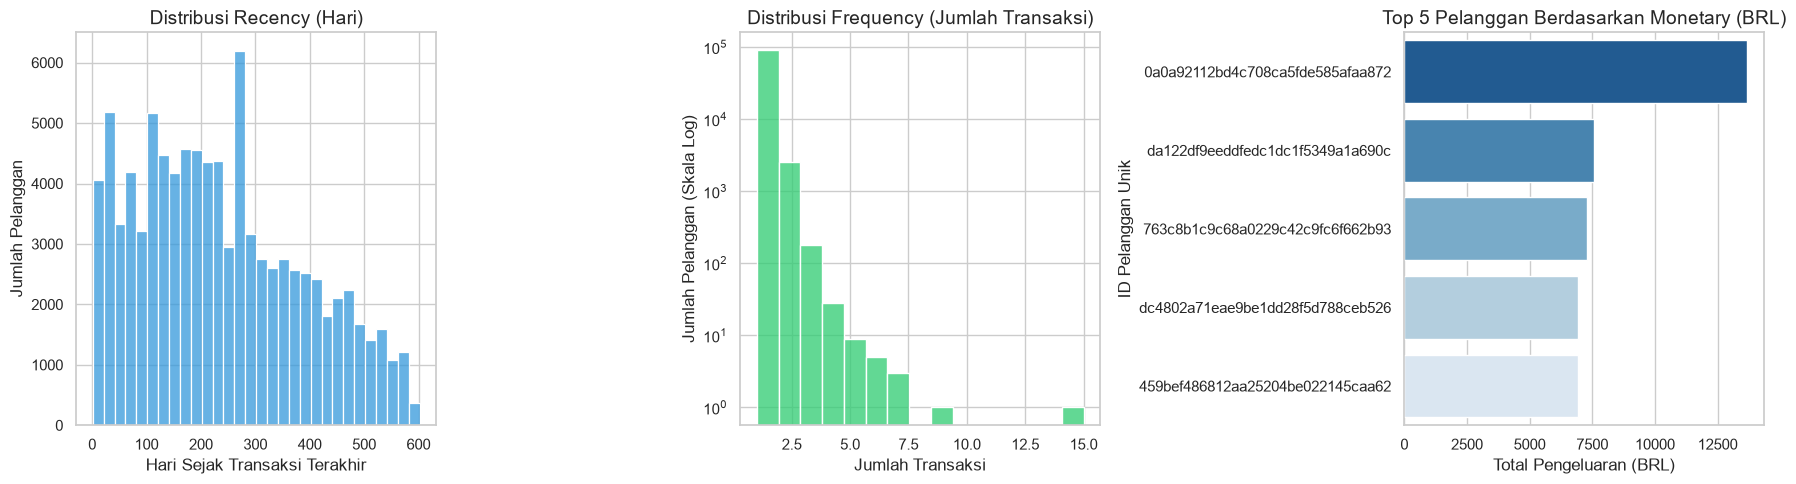

In [9]:
# Visualisasi parameter RFM
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Recency
sns.histplot(rfm_df['recency'], bins=30, color='#3498db', ax=axes[0])
axes[0].set_title('Distribusi Recency (Hari)', fontsize=14)
axes[0].set_xlabel('Hari Sejak Transaksi Terakhir')
axes[0].set_ylabel('Jumlah Pelanggan')

# 2. Frequency
sns.histplot(rfm_df['frequency'], bins=15, color='#2ecc71', ax=axes[1])
axes[1].set_title('Distribusi Frequency (Jumlah Transaksi)', fontsize=14)
axes[1].set_xlabel('Jumlah Transaksi')
axes[1].set_ylabel('Jumlah Pelanggan (Skala Log)')
axes[1].set_yscale('log')

# 3. Monetary (Top 5 Pelanggan Tertinggi)
top_monetary = rfm_df.sort_values(by='monetary', ascending=False).head(5)
sns.barplot(x='monetary', y='customer_unique_id', data=top_monetary, palette='Blues_r', ax=axes[2])
axes[2].set_title('Top 5 Pelanggan Berdasarkan Monetary (BRL)', fontsize=14)
axes[2].set_xlabel('Total Pengeluaran (BRL)')
axes[2].set_ylabel('ID Pelanggan Unik')

plt.tight_layout()
plt.show()

### Pertanyaan 2: Bagaimana performa ketepatan pengiriman dan pengaruhnya terhadap skor kepuasan pelanggan?

C:\Users\Satria Musthofa Azmi\AppData\Local\Temp\ipykernel_17596\19398285.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar_score = sns.barplot(


C:\Users\Satria Musthofa Azmi\AppData\Local\Temp\ipykernel_17596\19398285.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar_state = sns.barplot(


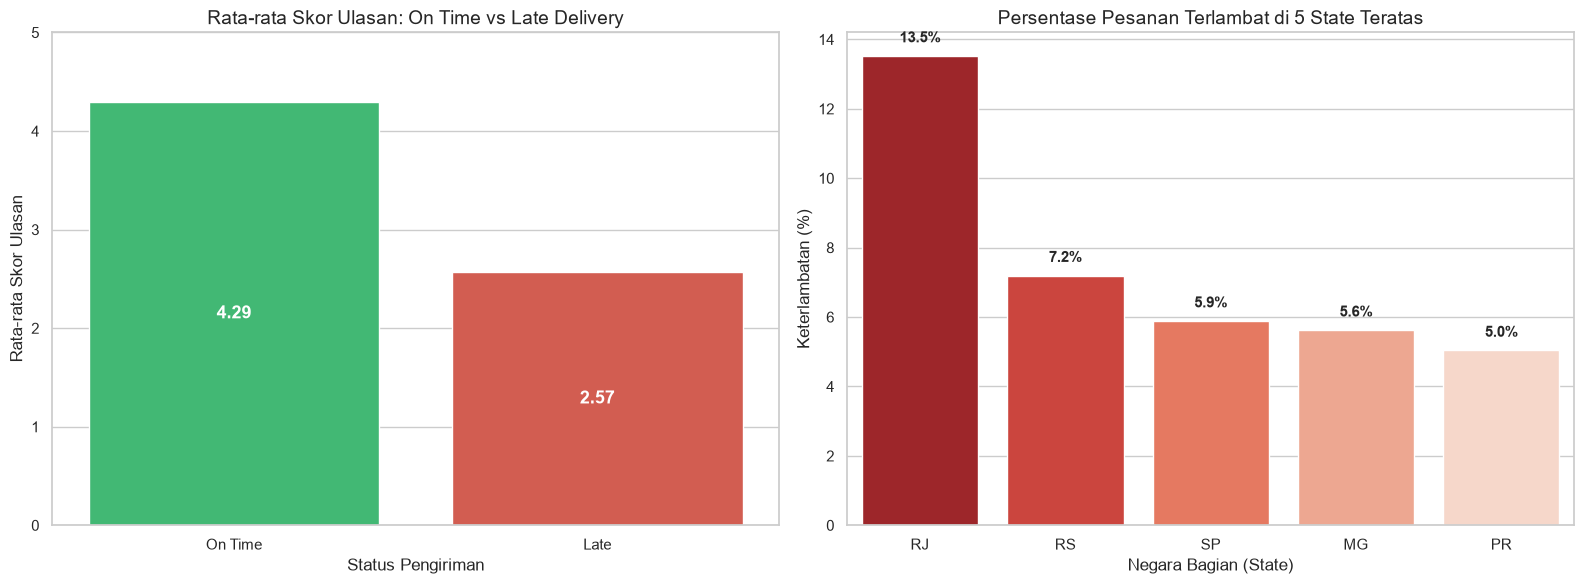

In [10]:
# Visualisasi pengaruh ketepatan pengiriman dan sebaran keterlambatan
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Rata-rata Skor Ulasan On Time vs Late
colors = {'On Time': '#2ecc71', 'Late': '#e74c3c'}
bar_score = sns.barplot(
    x='delivery_status', 
    y='review_score', 
    data=orders_full, 
    palette=colors, 
    errorbar=None, 
    ax=axes[0]
)
axes[0].set_title('Rata-rata Skor Ulasan: On Time vs Late Delivery', fontsize=14)
axes[0].set_xlabel('Status Pengiriman')
axes[0].set_ylabel('Rata-rata Skor Ulasan')
axes[0].set_ylim(0, 5)

for p in bar_score.patches:
    bar_score.annotate(f"{p.get_height():.2f}", 
                       (p.get_x() + p.get_width() / 2., p.get_height() / 2), 
                       ha='center', va='center', fontsize=13, color='white', weight='bold')

# Plot 2: Persentase Keterlambatan di 5 Negara Bagian Teratas
bar_state = sns.barplot(
    x='customer_state', 
    y='late_percentage', 
    data=state_perf, 
    palette='Reds_r', 
    ax=axes[1]
)
axes[1].set_title('Persentase Pesanan Terlambat di 5 State Teratas', fontsize=14)
axes[1].set_xlabel('Negara Bagian (State)')
axes[1].set_ylabel('Keterlambatan (%)')

for p in bar_state.patches:
    bar_state.annotate(f"{p.get_height():.1f}%", 
                       (p.get_x() + p.get_width() / 2., p.get_height() + 0.3), 
                       ha='center', va='bottom', fontsize=11, weight='bold')

plt.tight_layout()
plt.show()

## Analisis Lanjutan
### 1. RFM Customer Segmentation (Manual Grouping / Non-ML Clustering)

C:\Users\Satria Musthofa Azmi\AppData\Local\Temp\ipykernel_17596\2907108289.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bar_seg = sns.barplot(x='count', y='customer_segment', data=segment_counts, palette='viridis')


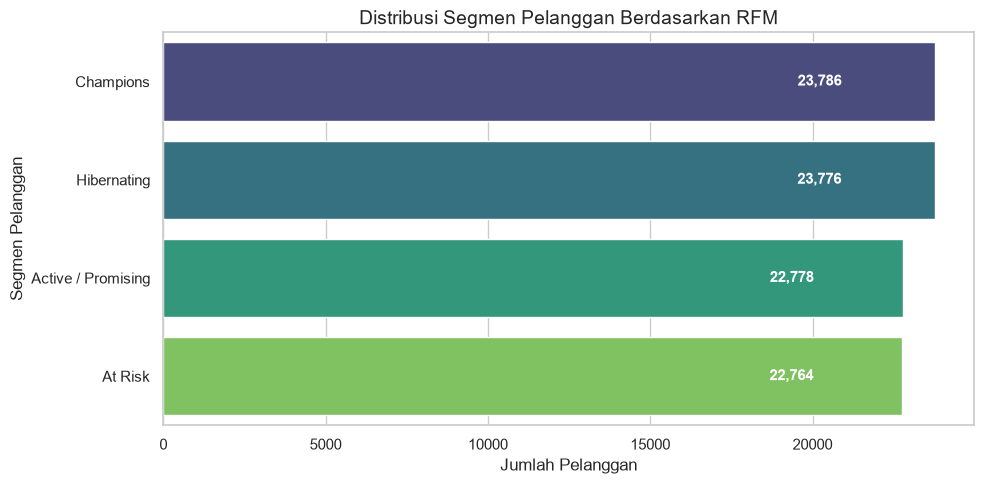

In [11]:
# Scoring kuantil sederhana untuk R dan M
r_labels = [4, 3, 2, 1]
m_labels = [1, 2, 3, 4]

rfm_df['r_score'] = pd.qcut(rfm_df['recency'], q=4, labels=r_labels).astype(int)
rfm_df['m_score'] = pd.qcut(rfm_df['monetary'], q=4, labels=m_labels).astype(int)

# Pengelompokan segmen pelanggan
def assign_segment(row):
    if row['r_score'] >= 3 and row['m_score'] >= 3:
        return 'Champions'
    elif row['r_score'] >= 3 and row['m_score'] < 3:
        return 'Active / Promising'
    elif row['r_score'] < 3 and row['m_score'] >= 3:
        return 'At Risk'
    else:
        return 'Hibernating'

rfm_df['customer_segment'] = rfm_df.apply(assign_segment, axis=1)

# Visualisasi distribusi segmen pelanggan
segment_counts = rfm_df['customer_segment'].value_counts().reset_index()
segment_counts.columns = ['customer_segment', 'count']

plt.figure(figsize=(10, 5))
bar_seg = sns.barplot(x='count', y='customer_segment', data=segment_counts, palette='viridis')
plt.title('Distribusi Segmen Pelanggan Berdasarkan RFM', fontsize=14)
plt.xlabel('Jumlah Pelanggan')
plt.ylabel('Segmen Pelanggan')

for p in bar_seg.patches:
    bar_seg.annotate(f"{int(p.get_width()):,}", 
                     (p.get_width() - (p.get_width()*0.15), p.get_y() + p.get_height() / 2), 
                     ha='center', va='center', fontsize=11, color='white', weight='bold')

plt.tight_layout()
plt.show()

### 2. Geospatial Analysis

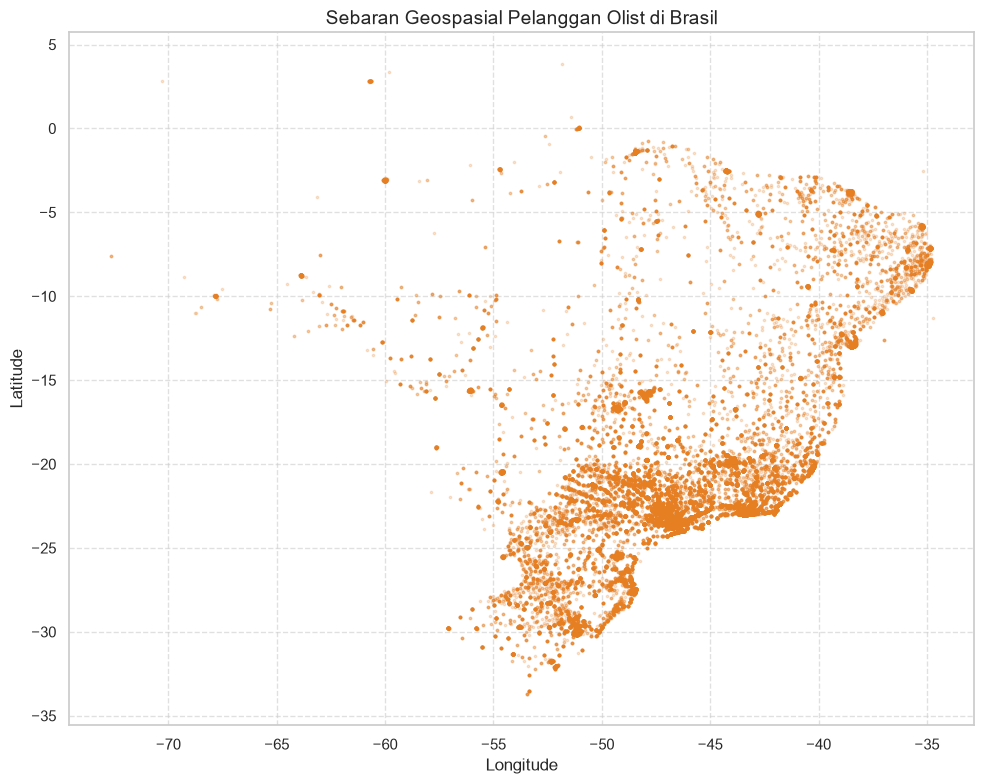

In [12]:
# Menggabungkan data pesanan dengan koordinat geolokasi
geo_orders = orders_full.merge(
    geo_clean, 
    left_on='customer_zip_code_prefix', 
    right_on='geolocation_zip_code_prefix', 
    how='inner'
)

# Memfilter batas wilayah daratan Brasil agar proporsional
geo_brazil = geo_orders[
    (geo_orders['geolocation_lat'] >= -35) & (geo_orders['geolocation_lat'] <= 5) &
    (geo_orders['geolocation_lng'] >= -75) & (geo_orders['geolocation_lng'] <= -30)
]

# Visualisasi sebaran pesanan pelanggan di Brasil
plt.figure(figsize=(10, 8))
plt.scatter(
    geo_brazil['geolocation_lng'], 
    geo_brazil['geolocation_lat'], 
    alpha=0.2, 
    s=3, 
    c='#e67e22'
)
plt.title('Sebaran Geospasial Pelanggan Olist di Brasil', fontsize=14)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Conclusion
- **Conclusion Pertanyaan 1**:
  Mayoritas pelanggan Olist melakukan transaksi satu kali dengan nilai rata-rata belanja sekitar 160 BRL. Penerapan segmentasi RFM berhasil mengidentifikasi 4 kelompok utama pelanggan (*Champions*, *Active / Promising*, *At Risk*, dan *Hibernating*). Kelompok *Champions* dan *At Risk* memegang kontribusi pendapatan yang signifikan sehingga memerlukan prioritas perhatian bisnis.
- **Conclusion Pertanyaan 2**:
  Ketepatan waktu pengiriman terbukti sangat berpengaruh terhadap kepuasan pelanggan. Pesanan yang tiba tepat waktu memiliki rata-rata skor ulasan 4,29, sedangkan pesanan terlambat anjlok menjadi 2,57. Dari 5 negara bagian dengan volume pesanan tertinggi, Rio de Janeiro (RJ) mencatat tingkat keterlambatan paling tinggi yaitu 13,52%, dibandingkan São Paulo (SP) yang hanya 5,88%.

## Rekomendasi Action Items
1. **Evaluasi dan Mitigasi Logistik Wilayah**: Tim operasional logistik perlu mengevaluasi mitra ekspedisi di wilayah dengan tingkat keterlambatan tinggi, khususnya Rio de Janeiro, serta menyesuaikan estimasi waktu pengiriman (*SLA margin*) untuk mengelola ekspektasi pembeli.
2. **Strategi Promosi Terarah Berbasis RFM**: Tim pemasaran dapat memberikan penawaran eksklusif dan layanan prioritas untuk menjaga loyalitas kelompok *Champions*, serta mengirimkan kupon diskon re-aktivasi (*win-back campaign*) kepada kelompok *At Risk* sebelum mereka beralih ke platform kompetitor.

## Menyimpan Data Bersih untuk Dashboard Streamlit

In [13]:
# Menyiapkan dataframe ringkas untuk kebutuhan dashboard
main_df = orders_full[[
    'order_id', 'customer_unique_id', 'customer_city', 'customer_state',
    'order_purchase_timestamp', 'order_delivered_customer_date', 
    'order_estimated_delivery_date', 'delivery_delay_days', 'delivery_status',
    'review_score'
]].copy()

# Menggabungkan total pembayaran per pesanan
main_df = main_df.merge(payment_per_order, on='order_id', how='left')

# Menggabungkan koordinat geolokasi
main_df = main_df.merge(
    geo_clean[['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng']],
    left_on=orders_full['customer_zip_code_prefix'],
    right_on='geolocation_zip_code_prefix',
    how='left'
).drop(columns=['geolocation_zip_code_prefix'])

# Menyimpan dataframe ke direktori dashboard
main_df.to_csv('dashboard/main_data.csv', index=False)
print("Data dashboard berhasil disimpan! Jumlah baris:", len(main_df))

Data dashboard berhasil disimpan! Jumlah baris: 96738
